In [1]:
import os
import sys
from pathlib import Path

ROOT = Path(os.getcwd()).resolve().parents[1]  # bart-playground root
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

notebook = "real1_Abalone"

In [2]:
import numpy as np
from ucimlrepo import fetch_ucirepo

# Load Abalone and drop categorical Sex
abalone = fetch_ucirepo(id=1)
X = abalone.data.features.drop(columns=["Sex"]).values.astype(float)
y = np.asarray(abalone.data.targets).reshape(-1)

X.shape, y.shape

((4177, 7), (4177,))

In [ ]:
import sys
from pathlib import Path

# Load the experiment runner from diagnosis/1M-iters/experiment.py
EXPERIMENT_DIR = ROOT / "diagnosis" / "1M-iters"
if str(EXPERIMENT_DIR) not in sys.path:
    sys.path.append(str(EXPERIMENT_DIR))
from experiment import run_parallel_experiments

# User-specified settings
ndpost = 1000000
store_every = 100
nskip = 0

results = run_parallel_experiments(
    X,
    y,
    ndpost=ndpost,
    nskip=nskip,
    n_trees=100,
    notebook=notebook,
    n_runs=2,
    n_chains=4,
    n_jobs=-2,
    store_every=store_every,
    store_dir="store",
    progress_print=True,
 )

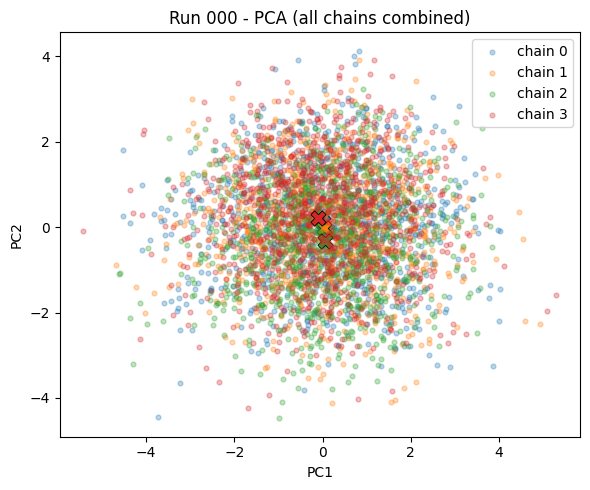

Run 000 centroids (PC1, PC2):
  chain 0: (0.0156, 0.1273)
  chain 1: (0.0315, -0.0157)
  chain 2: (0.0537, -0.3222)
  chain 3: (-0.1008, 0.2107)


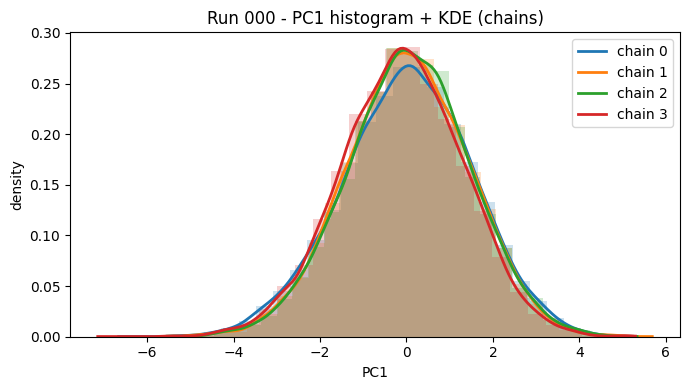

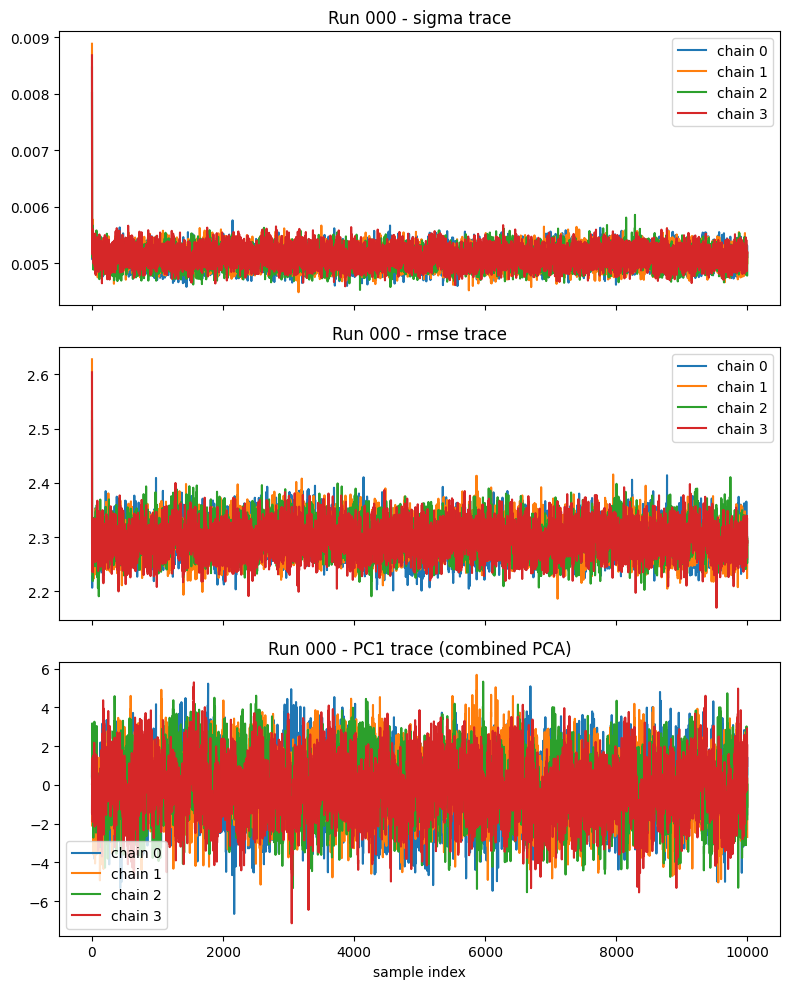

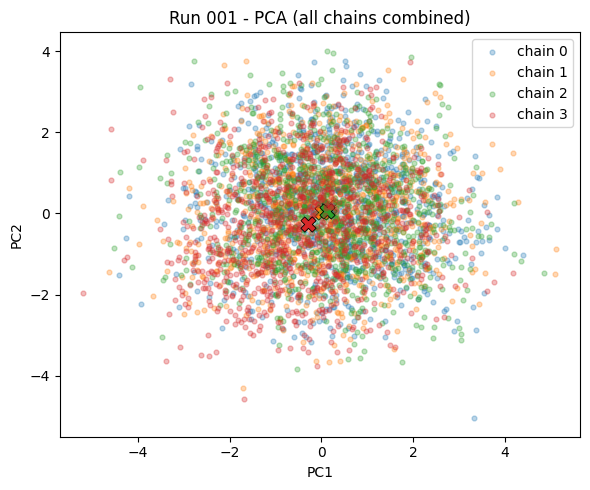

Run 001 centroids (PC1, PC2):
  chain 0: (0.1734, 0.1666)
  chain 1: (0.0110, 0.0443)
  chain 2: (0.1126, 0.0517)
  chain 3: (-0.2970, -0.2626)


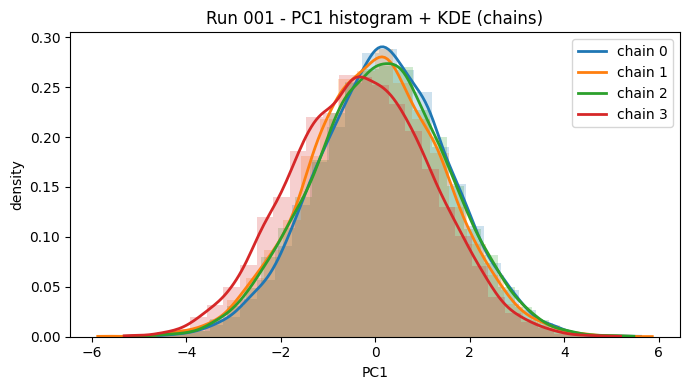

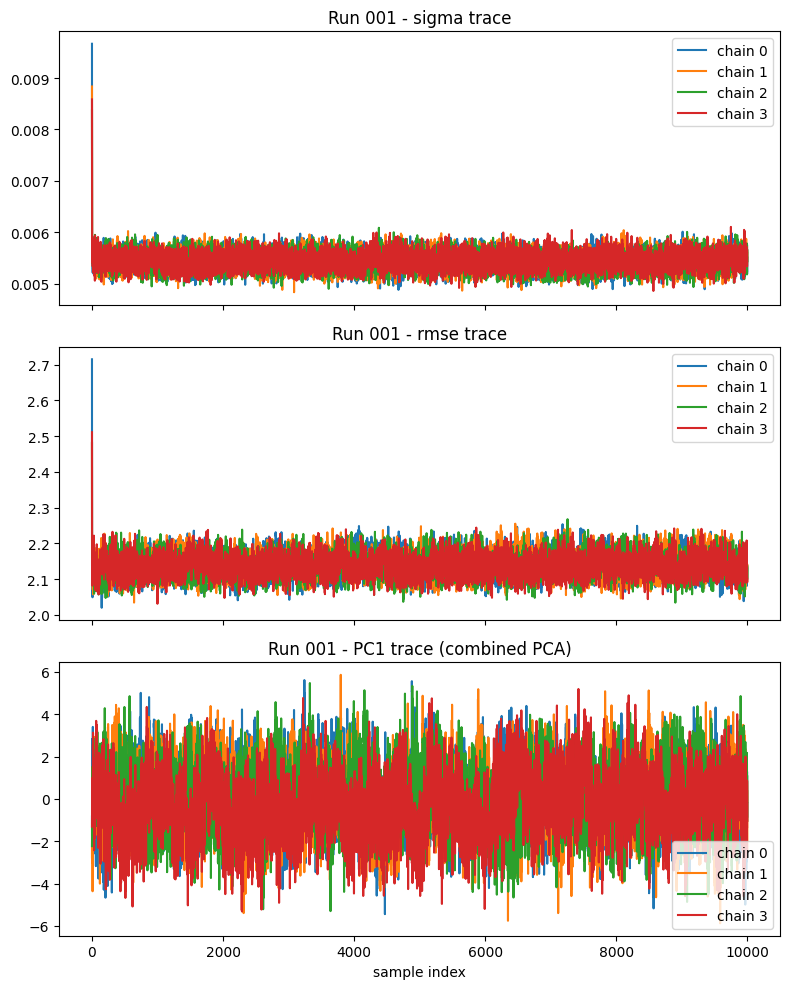

In [3]:
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA

STORE_DIR = ROOT / "diagnosis" / "1M-iters" / "store"
RUN_IDS = [0, 1]  # update if you have more runs
MODEL = "default"
NOTEBOOK_TAG = notebook
DOWNSAMPLE_PER_CHAIN = 1000  # number of points per chain in PCA scatter
SCATTER_ALPHA = 0.3
CHAIN_COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]  # high-contrast

def _load_with_shape(csv_path: Path):
    with open(csv_path, "r", encoding="utf-8") as f:
        header = f.readline().strip()
    if "original_shape=" not in header:
        raise ValueError(f"Missing original_shape in header: {csv_path}")
    shape_str = header.split("original_shape=")[-1]
    shape = ast.literal_eval(shape_str)
    data = np.loadtxt(csv_path, delimiter=",", comments="#")
    return data, shape

def _plot_pc1_hist_kde(pc1_groups, labels, colors, title):
    plt.figure(figsize=(7, 4))
    for data, label, color in zip(pc1_groups, labels, colors):
        data = np.asarray(data)
        plt.hist(
            data,
            bins=30,
            density=True,
            alpha=0.22,
            color=color,
            label="_nolegend_",
        )
        kde = gaussian_kde(data)
        xs = np.linspace(np.min(data), np.max(data), 200)
        plt.plot(xs, kde(xs), color=color, linewidth=2, label=label)
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("density")
    plt.legend()
    plt.tight_layout()
    plt.show()

for run_id in RUN_IDS:
    preds_path = STORE_DIR / "preds" / f"{NOTEBOOK_TAG}__run{run_id:03d}__{MODEL}__preds.csv"
    sigmas_path = STORE_DIR / "sigmas" / f"{NOTEBOOK_TAG}__run{run_id:03d}__{MODEL}__sigmas.csv"
    rmses_path = STORE_DIR / "rmses" / f"{NOTEBOOK_TAG}__run{run_id:03d}__{MODEL}__rmses.csv"

    preds_raw, preds_shape = _load_with_shape(preds_path)
    sigmas_raw, sigmas_shape = _load_with_shape(sigmas_path)
    rmses_raw, rmses_shape = _load_with_shape(rmses_path)

    preds = preds_raw.reshape(preds_shape)
    sigmas = sigmas_raw.reshape(sigmas_shape)
    rmses = rmses_raw.reshape(rmses_shape)

    n_chains = preds.shape[0]
    n_samples = preds.shape[2]
    colors = [CHAIN_COLORS[i % len(CHAIN_COLORS)] for i in range(n_chains)]

    # Fit PCA once per run using all chains together (all samples as rows).
    sample_vectors = preds.transpose(0, 2, 1).reshape(n_chains * n_samples, -1)
    pca = PCA(n_components=2, random_state=0)
    sample_coords = pca.fit_transform(sample_vectors)
    pc1 = sample_coords[:, 0].reshape(n_chains, n_samples)
    pc2 = sample_coords[:, 1].reshape(n_chains, n_samples)

    rng = np.random.default_rng(0)
    plt.figure(figsize=(6, 5))
    for c in range(n_chains):
        if DOWNSAMPLE_PER_CHAIN is not None and DOWNSAMPLE_PER_CHAIN < n_samples:
            idx = rng.choice(n_samples, size=DOWNSAMPLE_PER_CHAIN, replace=False)
        else:
            idx = np.arange(n_samples)
        plt.scatter(
            pc1[c][idx],
            pc2[c][idx],
            color=colors[c],
            s=12,
            alpha=SCATTER_ALPHA,
            label=f"chain {c}",
        )
        centroid_x = np.mean(pc1[c])
        centroid_y = np.mean(pc2[c])
        plt.scatter(
            centroid_x,
            centroid_y,
            color=colors[c],
            s=120,
            marker="X",
            edgecolor="black",
            linewidth=0.6,
        )
    plt.title(f"Run {run_id:03d} - PCA (all chains combined)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"Run {run_id:03d} centroids (PC1, PC2):")
    for c in range(n_chains):
        centroid_x = float(np.mean(pc1[c]))
        centroid_y = float(np.mean(pc2[c]))
        print(f"  chain {c}: ({centroid_x:.4f}, {centroid_y:.4f})")

    _plot_pc1_hist_kde(
        pc1_groups=[pc1[c] for c in range(n_chains)],
        labels=[f"chain {c}" for c in range(n_chains)],
        colors=colors,
        title=f"Run {run_id:03d} - PC1 histogram + KDE (chains)",
    )

    # Trace plots: sigmas, rmses, pc1 (PC1 from the combined PCA above)
    fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)
    for c in range(n_chains):
        axes[0].plot(sigmas[c], color=colors[c], label=f"chain {c}")
        axes[1].plot(rmses[c], color=colors[c], label=f"chain {c}")
        axes[2].plot(pc1[c], color=colors[c], label=f"chain {c}")
    axes[0].set_title(f"Run {run_id:03d} - sigma trace")
    axes[1].set_title(f"Run {run_id:03d} - rmse trace")
    axes[2].set_title(f"Run {run_id:03d} - PC1 trace (combined PCA)")
    axes[2].set_xlabel("sample index")
    for ax in axes:
        ax.legend()
    plt.tight_layout()
    plt.show()

run 000 | default centroid (PC1, PC2): (-0.3117, 1.4727)
run 000 | default_pt centroid (PC1, PC2): (0.6313, 0.7618)
run 000 | mtmh centroid (PC1, PC2): (0.3393, 1.9199)
run 000 | mtmh_pt centroid (PC1, PC2): (0.3448, 0.6724)


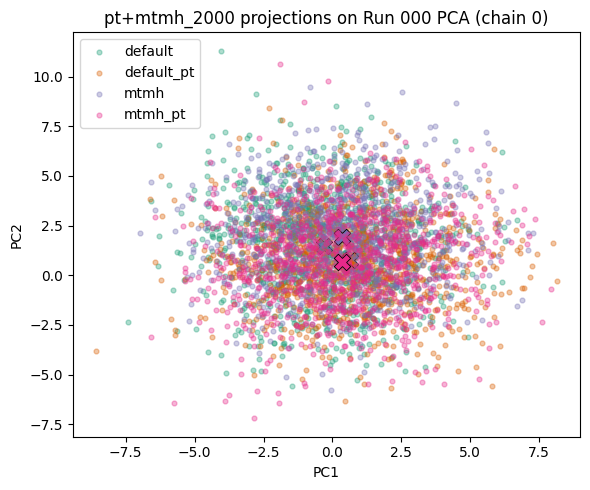

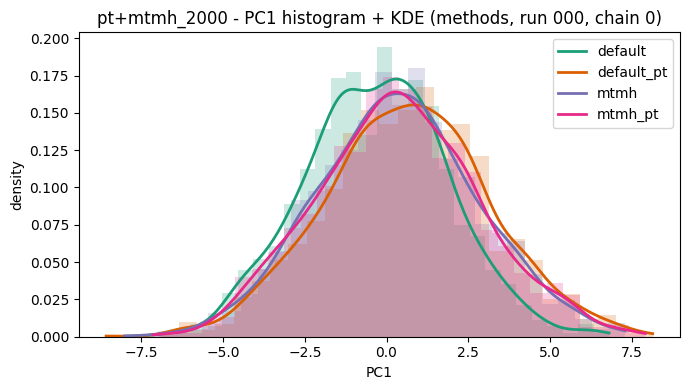

run 001 | default centroid (PC1, PC2): (0.0125, -0.0006)
run 001 | default_pt centroid (PC1, PC2): (-0.3465, -0.9077)
run 001 | mtmh centroid (PC1, PC2): (0.9412, -0.4654)
run 001 | mtmh_pt centroid (PC1, PC2): (-0.1487, -1.1231)


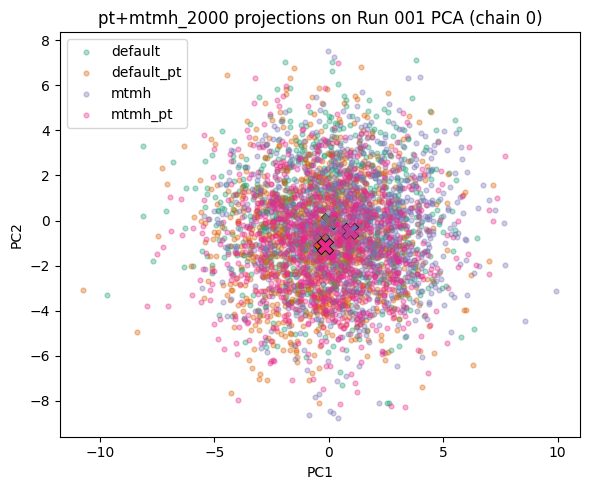

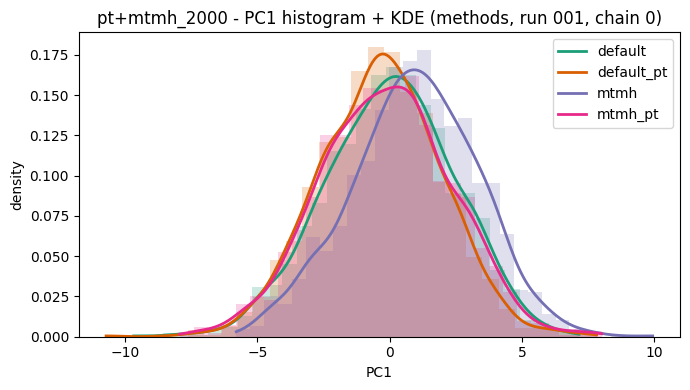

In [4]:
# Project pt+mtmh_2000 preds onto the PCA plane from this run (single chain only)
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA

BASE_STORE = ROOT / "diagnosis" / "1M-iters" / "store"
PT_STORE = ROOT / "diagnosis" / "pt+mtmh_2000" / "store"
RUN_IDS = [0, 1]  # update if you have more runs
CHAIN_ID = 0  # use a single chain for short-chain diagnostics
BURN_IN = 500
METHODS = ["default", "default_pt", "mtmh", "mtmh_pt"]
METHOD_COLORS = ["#1b9e77", "#d95f02", "#7570b3", "#e7298a"]
DOWNSAMPLE_PER_METHOD = 1000
SCATTER_ALPHA = 0.35

def _load_with_shape(csv_path: Path):
    with open(csv_path, "r", encoding="utf-8") as f:
        header = f.readline().strip()
    if "original_shape=" not in header:
        raise ValueError(f"Missing original_shape in header: {csv_path}")
    shape_str = header.split("original_shape=")[-1]
    shape = ast.literal_eval(shape_str)
    data = np.loadtxt(csv_path, delimiter=",", comments="#")
    return data, shape

def _plot_pc1_hist_kde(pc1_groups, labels, colors, title):
    plt.figure(figsize=(7, 4))
    for data, label, color in zip(pc1_groups, labels, colors):
        data = np.asarray(data)
        plt.hist(
            data,
            bins=30,
            density=True,
            alpha=0.22,
            color=color,
            label="_nolegend_",
        )
        kde = gaussian_kde(data)
        xs = np.linspace(np.min(data), np.max(data), 200)
        plt.plot(xs, kde(xs), color=color, linewidth=2, label=label)
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("density")
    plt.legend()
    plt.tight_layout()
    plt.show()

rng = np.random.default_rng(0)
for run_id in RUN_IDS:
    # Build PCA from the current run (all chains combined)
    base_preds_path = BASE_STORE / "preds" / f"{NOTEBOOK_TAG}__run{run_id:03d}__default__preds.csv"
    base_raw, base_shape = _load_with_shape(base_preds_path)
    base_preds = base_raw.reshape(base_shape)
    base_n_chains = base_preds.shape[0]
    base_n_samples = base_preds.shape[2]
    base_vectors = base_preds.transpose(0, 2, 1).reshape(base_n_chains * base_n_samples, -1)
    pca = PCA(n_components=2, random_state=0)
    pca.fit(base_vectors)

    method_pc1 = {}
    plt.figure(figsize=(6, 5))
    for method, color in zip(METHODS, METHOD_COLORS):
        preds_path = PT_STORE / "preds" / f"{NOTEBOOK_TAG}_pt_mtmh__run{run_id:03d}__{method}__preds.csv"
        preds_raw, preds_shape = _load_with_shape(preds_path)
        preds = preds_raw.reshape(preds_shape)
        chain_id = min(CHAIN_ID, preds.shape[0] - 1)
        chain_preds = preds[chain_id]
        if BURN_IN > 0:
            chain_preds = chain_preds[:, BURN_IN:]
        vectors = chain_preds.T
        coords = pca.transform(vectors)
        pc1 = coords[:, 0]
        pc2 = coords[:, 1]
        method_pc1[method] = pc1
        if DOWNSAMPLE_PER_METHOD is not None and DOWNSAMPLE_PER_METHOD < pc1.shape[0]:
            idx = rng.choice(pc1.shape[0], size=DOWNSAMPLE_PER_METHOD, replace=False)
        else:
            idx = np.arange(pc1.shape[0])
        plt.scatter(pc1[idx], pc2[idx], color=color, s=12, alpha=SCATTER_ALPHA, label=method)
        centroid_x = float(np.mean(pc1))
        centroid_y = float(np.mean(pc2))
        plt.scatter(
            centroid_x,
            centroid_y,
            color=color,
            s=140,
            marker="X",
            edgecolor="black",
            linewidth=0.6,
        )
        print(f"run {run_id:03d} | {method} centroid (PC1, PC2): ({centroid_x:.4f}, {centroid_y:.4f})")

    plt.title(f"pt+mtmh_2000 projections on Run {run_id:03d} PCA (chain {CHAIN_ID})")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

    _plot_pc1_hist_kde(
        pc1_groups=[method_pc1[m] for m in METHODS],
        labels=METHODS,
        colors=METHOD_COLORS,
        title=f"pt+mtmh_2000 - PC1 histogram + KDE (methods, run {run_id:03d}, chain {CHAIN_ID})",
    )

run 000 | default centroid (PC1, PC2): (2.5932, -1.1118)
run 000 | default_pt centroid (PC1, PC2): (-1.9017, -0.8592)
run 000 | mtmh centroid (PC1, PC2): (0.7404, 2.1281)
run 000 | mtmh_pt centroid (PC1, PC2): (-1.4319, -0.1570)


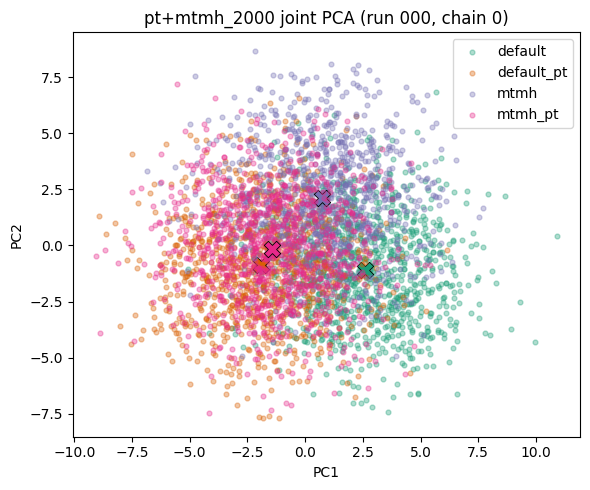

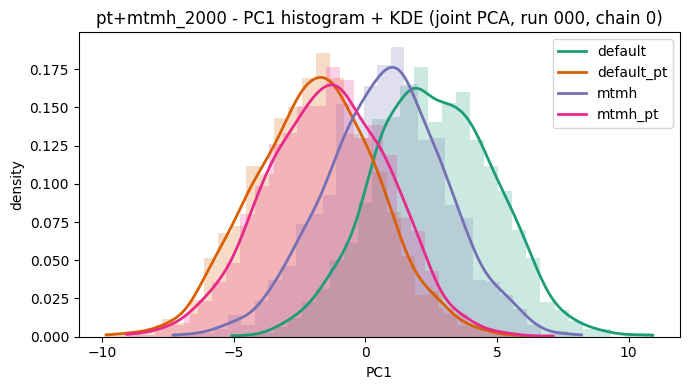

run 001 | default centroid (PC1, PC2): (3.0982, 0.0345)
run 001 | default_pt centroid (PC1, PC2): (-1.4444, -1.1258)
run 001 | mtmh centroid (PC1, PC2): (-0.3625, 1.8196)
run 001 | mtmh_pt centroid (PC1, PC2): (-1.2913, -0.7282)


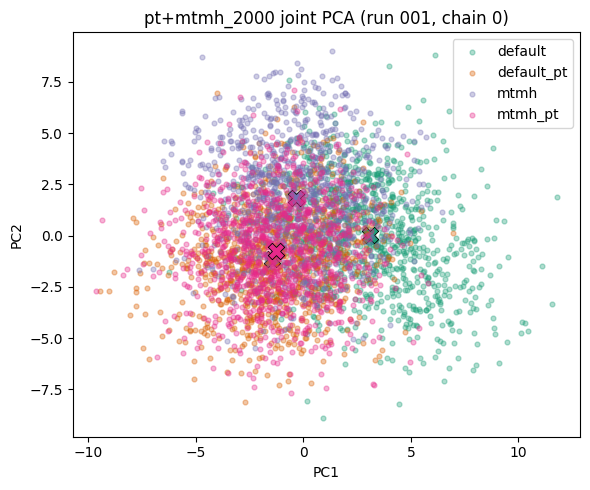

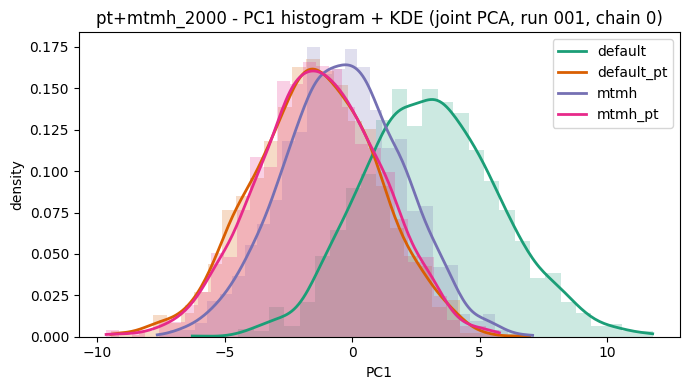

In [5]:
# Short-chain joint PCA plane (single chain, all methods combined)
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
from sklearn.decomposition import PCA

PT_STORE = ROOT / "diagnosis" / "pt+mtmh_2000" / "store"
RUN_IDS = [0, 1]  # update if you have more runs
CHAIN_ID = 0  # use a single chain for short-chain diagnostics
BURN_IN = 500
METHODS = ["default", "default_pt", "mtmh", "mtmh_pt"]
METHOD_COLORS = ["#1b9e77", "#d95f02", "#7570b3", "#e7298a"]
DOWNSAMPLE_PER_METHOD = 1000
SCATTER_ALPHA = 0.35

def _load_with_shape(csv_path: Path):
    with open(csv_path, "r", encoding="utf-8") as f:
        header = f.readline().strip()
    if "original_shape=" not in header:
        raise ValueError(f"Missing original_shape in header: {csv_path}")
    shape_str = header.split("original_shape=")[-1]
    shape = ast.literal_eval(shape_str)
    data = np.loadtxt(csv_path, delimiter=",", comments="#")
    return data, shape

def _plot_pc1_hist_kde(pc1_groups, labels, colors, title):
    plt.figure(figsize=(7, 4))
    for data, label, color in zip(pc1_groups, labels, colors):
        data = np.asarray(data)
        plt.hist(
            data,
            bins=30,
            density=True,
            alpha=0.22,
            color=color,
            label="_nolegend_",
        )
        kde = gaussian_kde(data)
        xs = np.linspace(np.min(data), np.max(data), 200)
        plt.plot(xs, kde(xs), color=color, linewidth=2, label=label)
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("density")
    plt.legend()
    plt.tight_layout()
    plt.show()

rng = np.random.default_rng(0)
for run_id in RUN_IDS:
    method_samples = {}
    joint_blocks = []
    joint_labels = []
    for method in METHODS:
        preds_path = PT_STORE / "preds" / f"{NOTEBOOK_TAG}_pt_mtmh__run{run_id:03d}__{method}__preds.csv"
        preds_raw, preds_shape = _load_with_shape(preds_path)
        preds = preds_raw.reshape(preds_shape)
        chain_id = min(CHAIN_ID, preds.shape[0] - 1)
        chain_preds = preds[chain_id]
        if BURN_IN > 0:
            chain_preds = chain_preds[:, BURN_IN:]
        method_samples[method] = chain_preds
        joint_blocks.append(chain_preds.T)
        joint_labels.append(np.repeat(method, chain_preds.shape[1]))

    joint_predictions = np.vstack(joint_blocks)
    joint_labels = np.concatenate(joint_labels)
    pca = PCA(n_components=2, random_state=0)
    joint_coords = pca.fit_transform(joint_predictions)

    plt.figure(figsize=(6, 5))
    for method, color in zip(METHODS, METHOD_COLORS):
        coords = joint_coords[joint_labels == method]
        pc1 = coords[:, 0]
        pc2 = coords[:, 1]
        if DOWNSAMPLE_PER_METHOD is not None and DOWNSAMPLE_PER_METHOD < pc1.shape[0]:
            idx = rng.choice(pc1.shape[0], size=DOWNSAMPLE_PER_METHOD, replace=False)
        else:
            idx = np.arange(pc1.shape[0])
        plt.scatter(pc1[idx], pc2[idx], color=color, s=12, alpha=SCATTER_ALPHA, label=method)
        centroid_x = float(np.mean(pc1))
        centroid_y = float(np.mean(pc2))
        plt.scatter(
            centroid_x,
            centroid_y,
            color=color,
            s=140,
            marker="X",
            edgecolor="black",
            linewidth=0.6,
        )
        print(f"run {run_id:03d} | {method} centroid (PC1, PC2): ({centroid_x:.4f}, {centroid_y:.4f})")

    plt.title(f"pt+mtmh_2000 joint PCA (run {run_id:03d}, chain {CHAIN_ID})")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

    _plot_pc1_hist_kde(
        pc1_groups=[joint_coords[joint_labels == method][:, 0] for method in METHODS],
        labels=METHODS,
        colors=METHOD_COLORS,
        title=f"pt+mtmh_2000 - PC1 histogram + KDE (joint PCA, run {run_id:03d}, chain {CHAIN_ID})",
    )